In [1]:
!pip install --upgrade pip --quiet

In [2]:
!pip install --upgrade numpy --quiet

In [3]:
!pip install --upgrade pandas --quiet

In [4]:
!pip install --upgrade scipy --quiet

In [5]:
!pip install --upgrade statsmodels --quiet

In [6]:
!pip install --upgrade matplotlib --quiet

In [7]:
!pip install --upgrade seaborn --quiet

In [8]:
!pip install --upgrade networkx --quiet

In [9]:
import numpy as np

In [10]:
import pandas as pd

In [11]:
import matplotlib.pyplot as plt

In [12]:
import seaborn as sns

In [13]:
import statsmodels.formula.api as smf

In [14]:
import networkx as nx

In [15]:
from scipy import stats

In [16]:
from IPython.display import YouTubeVideo, IFrame

In [17]:
def diferenca_de_medias(dados, tratamento, resultado):
    """Diferença simples de médias entre tratados e controles."""
    g = dados.groupby(tratamento)[resultado].agg(["count", "mean"])
    dif = g.loc[1, "mean"] - g.loc[0, "mean"]
    return g, dif

In [18]:
def desenha_dag(arestas, titulo="", posicoes=None, no_cor=None):
    """Desenha um DAG a partir de uma lista de arestas (causa, efeito)."""
    G = nx.DiGraph()
    G.add_edges_from(arestas)
    pos = posicoes if posicoes else nx.spring_layout(G, seed=42)
    cores = [no_cor.get(n, "#cfe8ef") if no_cor else "#cfe8ef" for n in G.nodes]
    plt.figure(figsize=(7, 2.6))
    nx.draw(G, pos, with_labels=True, node_color=cores, node_size=2600,
            font_size=9, font_weight="bold", arrowsize=22, edge_color="#555")
    plt.title(titulo, fontsize=11)
    plt.margins(0.15);
    return G

In [19]:
def balanco_covariaveis(dados, tratamento, covariaveis):
    """Compara a média das covariáveis entre tratados e controles."""
    linhas = []
    for v in covariaveis:
        m1 = dados.loc[dados[tratamento] == 1, v].mean()
        m0 = dados.loc[dados[tratamento] == 0, v].mean()
        linhas.append({"covariavel": v, "tratados": m1,
                       "controles": m0, "diferenca": m1 - m0})
    return pd.DataFrame(linhas)

# Avaliação de Políticas Públicas com Dados 📊

<p style="text-align: right">Prof. <a href="https://www.linkedin.com/in/heliomacedofilho/">Hélio Bomfim de Macêdo Filho</a><br />
<a href="https://www.idp.edu.br/mestrado/profissional-em-ciencia-de-dados">Mestrado em Administração Pública:<br />Ciência de Dados e Inteligência Artificial no Setor Público</a></p>

## Módulo 01 — Fundamentos: Causalidade, Resultados Potenciais e DAGs

## Sumário
<ul>
    <li>Cenário 🗺️</li>
    <li>Correlação ≠ Causalidade ‼️</li>
    <ul>
        <li>O Bolsa Família "reduz" a frequência escolar?</li>
        <li>O Paradoxo de Simpson</li>
    </ul>
    <li>Resultados Potenciais 🎲</li>
    <ul>
        <li>Os dois mundos de cada criança</li>
        <li>O problema fundamental</li>
        <li>ATE, ATT e ATU</li>
    </ul>
    <li>SUTVA</li>
    <li>Viés de Seleção ⚖️</li>
    <li>Grafos Acíclicos Direcionados (DAGs) 🕸️</li>
    <li>Bons e Maus Controles</li>
    <li>Síntese e Próximo Módulo</li>
</ul>

👉 Esta é a primeira de **8 aulas**. O curso inteiro responde a uma pergunta:

> *Como saber se uma política pública **causou** o resultado que observamos?*

🚨 Atenção a uma distinção que vamos repetir o semestre todo:

- **Predição** (o que vocês já dominam): *dado o que observo, o que vai acontecer?*
- **Inferência causal** (o foco deste curso): *se eu **intervir**, o que vai mudar?*

Para decidir uma política, 
- um modelo pode prever muito bem e ainda assim ser inútil (ou enganoso).

👉 Leitura de apoio desta aula (todas gratuitas online):

- FACURE, M. *<a href="https://matheusfacure.github.io/python-causality-handbook/">Causal Inference for the Brave and True</a>*, caps. 1 e 4.
- CUNNINGHAM, S. *<a href="https://mixtape.scunning.com/04-potential_outcomes">Causal Inference: The Mixtape</a>*, cap. 4.
- CINELLI, C.; FORNEY, A.; PEARL, J. (2022). *<a href="https://ftp.cs.ucla.edu/pub/stat_ser/r493.pdf">A Crash Course in Good and Bad Controls</a>*.

🚨 **Antes de começar — arquivo de dados.** 🎲

Usaremos a Avaliação de Impacto do Bolsa Família (AIBF II), módulo de educação.

👉 Os microdados são públicos e desidentificados. Distribuídos pela 
- Secretaria de Avaliação, Gestão da Informação e Cadastro Único (Sagicad) do
- Ministério do Desenvolvimento e Assistência Social, Família e Combate à Fome (MDS). 

Fonte: <a href="https://aplicacoes.mds.gov.br/sagicad/pesquisas/lista-s.php?stk=ano&i=2012">Pesquisa de Avaliação de Impacto do Programa Bolsa Família (AIBF II)</a>

### Saiba Mais 👩‍🏫

👉 <a href="https://www.gov.br/mds/pt-br/orgaos/SAGICAD/estudos-e-pesquisas/manuais">Manual do Pesquisador</a>, Programa Bolsa Família.

## Cenário 🗺️

Vamos trabalhar o curso inteiro com **um caso real**:

> O **Programa Bolsa Família (PBF)** aumentou a **frequência escolar** das crianças beneficiárias?

O PBF é um programa de **transferência de renda condicionada**, obtido por
- pesquisa domiciliar com famílias beneficiárias e não-beneficiárias.

Entre as condicionalidades:

- crianças e adolescentes precisam manter **frequência escolar mínima**;
- a família precisa cumprir o calendário de **saúde** (vacinação, pré-natal).

🚨 **Atenção**

As famílias não foram sorteadas para receber o PBF. 

Isto é, a AIBF II **não** é um experimento aleatorizado. 

Portanto, o que faremos hoje é uma comparação **observacional**.

👉 No fim da aula vocês vão entender *por que* isso impede a leitura causal ingênua...

... nas próximas aulas veremos os métodos que tornam a comparação crível.

👉 Vamos carregar os dados.

In [20]:
df = pd.read_csv("data/educacao_completo.csv", low_memory=False)
df.shape

(56367, 342)

👉 Cada linha é uma **pessoa**. 
- A coluna `cod_dtm` identifica unicamente um **domicílio**.
- Demais colunas no próximo slide.

In [21]:
df[["cod_dtm", "s02af", "s02ad", "s02a17", "s02a21", "s00a1", 
    "s02a10", "p_attend7", "dropout", "if_miss30"]].head()

,cod_dtm,s02af,s02ad,s02a17,s02a21,s00a1,s02a10,p_attend7,dropout,if_miss30
0,1,52.0,1.0,3.0,4.0,11.0,2.0,NaN,NaN,NaN
1,1,33.0,2.0,2.0,4.0,11.0,1.0,NaN,1.0,NaN
2,1,10.0,1.0,2.0,NaN,11.0,2.0,1.0,0.0,1.0
3,1,8.0,1.0,2.0,NaN,11.0,2.0,1.0,0.0,0.0
4,2,63.0,2.0,NaN,NaN,11.0,NaN,NaN,NaN,NaN


Algumas variáveis que vamos usar (os nomes vêm do questionário original):

| Coluna | Significado |
|---|---|
| `cod_dtm` | identificador do domicílio |
| `s02af` | idade em anos |
| `s02ad` | sexo (1 = masculino, 2 = feminino) |
| `s02a17` | cor/raça (1 branca, 2 preta, 3 parda, 4 amarela, 5 indígena) |
| `s02a21` | situação do domicílio (2 e 4 = rural) |
| `s00a1` | unidade da federação |
| `s02a10` | a pessoa é titular do cartão do Bolsa Família? (1 = sim; 2 = não) |
| `p_attend7` | proporção de dias letivos em que a criança foi à escola (últimos 7 dias) |
| `dropout` | evasão escolar (1 = abandonou), p/ quem estudava no ano anterior |
| `if_miss30` | faltou à escola nos últimos 30 dias? (1 = sim) |

### O vocabulário da avaliação 🔤

👉 Antes de medir qualquer efeito, precisamos nomear os elementos do problema.

**Variável.** Qualquer característica que assume valores diferentes entre os registros — idade, sexo, frequência escolar, região. 

No DataFrame, é uma **coluna**.  Nem toda variável tem o mesmo papel: 
- o que define o papel é a *pergunta causal*,
- não o dado em si.

**Unidade de análise.** A entidade sobre a qual medimos e a quem o efeito se refere.

👉 É preciso distingui-la da **unidade de observação**: a linha da tabela.

🚨 No nosso caso, 
- cada linha/unidade de observação é uma **pessoa**
    - (o responsável familiar que respondeu?),
- cada unidade de análise é uma **criança de 6 a 17 anos**, ainda que o 
- Bolsa Família seja recebida pela **família**. 

Por isso, o tratamento será definido no nível do **domicílio** (`cod_dtm`).

**Variável de tratamento** ($D$). A variável cujo efeito queremos estimar — a "causa" sob investigação. 

No nosso caso é binária: 
- $D=1$ se o domicílio recebe o PBF,
- $D=0$ caso contrário.

O tratamento é o que, idealmente, poderíamos *intervir* para mudar.

**Variável de desfecho** ($Y$, *outcome*). A variável sobre a qual queremos saber se o tratamento teve efeito — a "consequência" sob investigação. 

No nosso caso, é a frequência escolar (`p_attend7`).

🚨 Tratamento e desfecho não são propriedades fixas de uma coluna.

Numa outra pergunta, a frequência escolar poderia ser o tratamento (e não o desfecho).

**População.** O conjunto completo de unidades sobre o qual queremos que a conclusão valha.

Por exemplo, *todas as crianças de 6 a 17 anos de famílias de baixa renda no Brasil*. 

Quase nunca a observamos inteira: 
- trabalhamos com uma **amostra**,
- e a pesquisa AIBF II é uma amostra dessa população.

👉 Distinguir população de amostra é o que mais tarde vai separar duas perguntas diferentes: 
- *o efeito nesta amostra* (validade interna) e
- *o efeito na população* (validade externa).

ℹ️ Fixando o vocabulário no nosso caso:

| Conceito | No estudo do Bolsa Família |
|---|---|
| Unidade de observação | a pessoa (cada linha da tabela) |
| Unidade de análise | a criança de 6 a 17 anos |
| Variável de tratamento $D$ | domicílio recebe o PBF (sim/não) |
| Variável de desfecho $Y$ | frequência escolar (`p_attend7`) |
| Covariáveis $X$ | idade, sexo, raça, zona, região... |
| População-alvo | crianças de famílias de baixa renda no Brasil |
| Amostra | os domicílios pesquisados na AIBF II |

### Definindo a Unidade e o Tratamento 🎯

🚨 **Primeira decisão de qualquer avaliação: o que é o "tratamento"?**

A variável `s02a10` indica quem é **titular do cartão**.

- em geral, *uma* pessoa por família (frequentemente a mãe); e
- a criança não é titular do cartão.

👉 Lembrete: `s02a10`: a pessoa é titular do cartão do Bolsa Família? (1 = sim; 2 = não)

ℹ️ A criança é "tratada" se **vive em um domicílio beneficiário**.

Então construímos o tratamento **no nível do domicílio** e o atribuímos a cada pessoa:

> `D = 1` se **algum** morador do domicílio é titular do cartão do PBF.

In [22]:
tratamento_dom = (
    df.groupby("cod_dtm")["s02a10"]
      .apply(lambda s: int((s == 1).any()))
      .rename("D")
)
tratamento_dom.head()

cod_dtm
1    1
2    1
3    0
4    0
6    0
Name: D, dtype: int64

👉 `D` está agora em todas as pessoas.

In [23]:
df = df.merge(tratamento_dom, on="cod_dtm", how="left")
df["D"].value_counts()

D
1    34437
0    21930
Name: count, dtype: int64

Vamos checar quantos domicílios há de cada lado.

In [24]:
df.groupby("D")["cod_dtm"].nunique()

D
0    4830
1    6542
Name: cod_dtm, dtype: int64

👉 Note que isso já é uma **escolha metodológica**. 

Poderíamos definir o tratamento de outras formas (valor do benefício, tempo de permanência...). 

Voltaremos a isso quando falarmos de **SUTVA**.

## Correlação ≠ Causalidade ‼️

Vamos focar 
- nas **crianças e adolescentes em idade escolar (6 a 17 anos)**
- e que têm a medida de frequência `p_attend7`.

In [25]:
criancas = df[
    df["s02af"].between(6, 17) & 
    df["p_attend7"].notna()].\
    copy().\
    rename(columns={"p_attend7": "Y"})

In [26]:
criancas[["cod_dtm", "s02af", "s02ad", "D", "Y"]].head()

,cod_dtm,s02af,s02ad,D,Y
2,1,10.0,1.0,1,1.0
3,1,8.0,1.0,1,1.0
6,2,8.0,2.0,1,1.0
25,7,17.0,1.0,0,1.0
26,7,14.0,2.0,0,1.0


In [27]:
print("crianças:", len(criancas))

crianças: 12441


In [28]:
print("crianças tratadas:", int((criancas["D"] == 1).sum()))

crianças tratadas: 8848


In [29]:
print("crianças controle:", int((criancas["D"] == 0).sum()))

crianças controle: 3593


### O Bolsa Família 'reduz' a frequência escolar? 🤔

👉 A pergunta ingênua: *qual a frequência média de cada grupo?*

In [30]:
tabela, dif = diferenca_de_medias(criancas, "D", "Y")
tabela

,count,mean
D,,
0,3593,0.967694
1,8848,0.966255


In [31]:
print(f"Diferença simples (tratados - controle): {dif:.4f}")

Diferença simples (tratados - controle): -0.0014


🚨 A diferença é **negativa** — porém minúscula: cerca de **−0,001**, praticamente **zero**.

Lido sem cuidado, isso vira a manchete: 
- *"O Bolsa Família não faz diferença na frequência escolar."* 

Guardem esta leitura — vamos desmontá-la.

<details>
  <summary>Essa conclusão está correta? Pense antes de abrir.</summary>

**Não.** A diferença simples de médias compara dois grupos que **já eram diferentes
antes do programa**.

Quem entra no Bolsa Família é, por desenho do programa, mais pobre e mais vulnerável.
Essas famílias enfrentam mais barreiras para manter a criança na escola —
**independentemente** de receber o benefício.

Estamos comparando coisas não comparáveis. O número `−0,001` mistura o efeito do
programa com a diferença pré-existente entre os grupos. Esse "tempero indesejado"
tem nome: **viés de seleção** — e é o assunto central do módulo.
</details>

👉 Vamos *ver* essa diferença pré-existente. 
- As crianças dos dois grupos têm o mesmo perfil?

In [32]:
criancas["rural"] = criancas["s02a21"].isin([2, 4]).astype(int)
criancas["feminino"] = (criancas["s02ad"] == 2).astype(int)
criancas["preta_parda"] = criancas["s02a17"].isin([2, 3]).astype(int)

👉 Os grupos diferem em composição (raça, zona rural, idade...). 

In [33]:
balanco_covariaveis(criancas, "D",
                    ["s02af", "feminino", "rural", "preta_parda"])

,covariavel,tratados,controles,diferenca
0,s02af,11.841885,12.021431,-0.179545
1,feminino,0.493897,0.482327,0.011570
2,rural,0.058657,0.034233,0.024424
3,preta_parda,0.687952,0.602282,0.085670


Ou seja: **não** estamos diante de um experimento. 

Guardem esta tabela — vamos voltar a ela.

### O Paradoxo de Simpson 🔀

Um exemplo clássico de como uma comparação "agregada" pode enganar.

Vamos olhar a diferença de frequência entre tratados e controle 
- **dentro de cada faixa etária**.

In [34]:
criancas["faixa"] = np.where(criancas["s02af"] <= 11,
                              "06-11 anos", "12-17 anos")

In [35]:
(criancas
 .groupby(["faixa", "D"])["Y"]
 .mean()
 .unstack("D")
 .rename(columns={0: "controle", 1: "tratado"})
 .assign(diferenca=lambda t: t["tratado"] - t["controle"]))

D,controle,tratado,diferenca
faixa,,,
06-11 anos,0.971992,0.966225,-0.005767
12-17 anos,0.964493,0.966280,0.001787


👉 O sinal e o tamanho da diferença **mudam** conforme a faixa.

🚨 **Paradoxo de Simpson:** uma associação observada no agregado pode se inverter (ou sumir) quando olhamos dentro de subgrupos.

P: Qual número é "o certo"?

R: Nenhum deles, isoladamente — a pergunta está mal formulada.

ℹ️ Precisamos de uma **linguagem** que diga, *antes* de olhar os dados, quais comparações fazem sentido. 

Essa linguagem tem dois dialetos:

- os **resultados potenciais** (Neyman–Rubin);
- os **grafos causais / DAGs** (Pearl).

Vamos aos dois.

### O que é um efeito causal? 🎯

👉 Antes da linguagem formal, a ideia central.

O **efeito causal** do tratamento sobre uma unidade é
- a **diferença entre dois estados do mesmo mundo**:
    - o que aconteceria com aquela unidade *com* o tratamento; e
    - o que aconteceria *sem* o tratamento — **mantido todo o resto constante**.

🚨 A expressão "mantido todo o resto constante" é o nó do problema. 

Comparar uma criança beneficiária com **outra** criança não beneficiária 
- não mantém o resto constante: são pessoas diferentes, com histórias diferentes.

O efeito causal exige comparar a **mesma** unidade nos dois estados
— e é justamente isso que nunca conseguimos observar diretamente.

ℹ️ É essa impossibilidade que a próxima seção formaliza, com a linguagem dos **resultados potenciais**.

## Resultados Potenciais 🎲

### Os dois mundos de cada criança 🌗

Para **cada criança** $i$, imagine dois mundos possíveis:

- $Y_i(1)$ — a frequência escolar dela **se a família recebe** o Bolsa Família;
- $Y_i(0)$ — a frequência escolar dela **se a família não recebe**.

Esses são os **resultados potenciais** (*potential outcomes*).

O **efeito do tratamento** para a criança $i$ é a diferença entre os dois mundos:

$$\tau_i = Y_i(1) - Y_i(0)$$

🚨 **O problema fundamental da inferência causal** (Holland, 1986):

> Para cada criança observamos **apenas um** dos dois mundos.
> Se a família recebe o PBF, vemos $Y_i(1)$ e **nunca saberemos** $Y_i(0)$.

O resultado potencial não observado é o **contrafactual**.

👉 A ponte entre o que **imaginamos** ($Y(0), Y(1)$) e o que **observamos** ($Y$):

$$Y_i = D_i \cdot Y_i(1) + (1 - D_i) \cdot Y_i(0),$$
chamada de *switching equation*. 

O tratamento $D_i$ funciona como uma chave: liga um mundo, desliga o outro.

👉 Vamos tornar isso concreto. Imagine **4 crianças** com os **dois mundos visíveis**.

In [36]:
mundos = pd.DataFrame({
    "crianca":  ["Ana", "Bruno", "Carla", "Diego"],
    "Y0":       [0.70, 0.95, 0.60, 0.99],   # frequência SEM o PBF
    "Y1":       [0.92, 0.97, 0.85, 0.99],   # frequência COM o PBF
})
mundos["efeito_tau"] = mundos["Y1"] - mundos["Y0"]
mundos

,crianca,Y0,Y1,efeito_tau
0,Ana,0.70,0.92,0.22
1,Bruno,0.95,0.97,0.02
2,Carla,0.60,0.85,0.25
3,Diego,0.99,0.99,0.00


👉 Repare: o efeito $\tau_i$ **varia entre as crianças**.

- Ana e Carla (mais vulneráveis) ganham muito;
- Bruno ganha pouco;
- Diego já frequentava 99% — efeito praticamente nulo.

Isso é **heterogeneidade do efeito**.

🚨 Mas, na realidade, só enxergamos **uma coluna por criança**. 

Vamos simular o sorteio do mundo.

In [37]:
np.random.seed(42)
mundos["D"] = np.random.binomial(1, 0.5, size=len(mundos))
mundos["Y_observado"] = np.where(mundos["D"] == 1, 
                                 mundos["Y1"], mundos["Y0"])
mundos[["crianca", "D", "Y_observado"]]

,crianca,D,Y_observado
0,Ana,0,0.70
1,Bruno,1,0.97
2,Carla,1,0.85
3,Diego,1,0.99


👉 Esta é a tabela que a vida real nos entrega. 

As colunas `Y0`, `Y1` e `efeito_tau` ficam **escondidas**. 
- O contrafactual virou um ponto de interrogação.

In [38]:
realidade = mundos[["crianca", "D", "Y_observado"]].copy()
realidade["Y0"] = np.where(realidade["D"] == 0, mundos["Y0"], np.nan)
realidade["Y1"] = np.where(realidade["D"] == 1, mundos["Y1"], np.nan)
realidade

,crianca,D,Y_observado,Y0,Y1
0,Ana,0,0.70,0.7,NaN
1,Bruno,1,0.97,NaN,0.97
2,Carla,1,0.85,NaN,0.85
3,Diego,1,0.99,NaN,0.99


🚨 Inferência causal é, no fundo, **um problema de dados faltantes**:
- toda a metade contrafactual da tabela está em branco.

### ATE, ATT e ATU 📐

Se não medimos $\tau_i$ pessoa a pessoa, miramos em **médias** (*Average Treatment*). 

Três delas importam:

- **ATE** — efeito médio na população inteira (*Effect*): $$ATE = E[\,Y(1) - Y(0)\,]$$
- **ATT** — efeito médio **sobre os tratados** (*on the Treated*): $$ATT = E[\,Y(1) - Y(0)\mid D = 1\,]$$
- **ATU** — efeito médio **sobre os não-tratados** (*on the Untreated*): $$ATU = E[\,Y(1) - Y(0)\mid D = 0\,]$$

👉 Cada um responde a uma pergunta de política diferente:

- O **ATT** pergunta: *o programa funcionou para quem o recebeu?* — avaliação clássica.
- O **ATU** pergunta: *valeria a pena estender o programa a quem hoje não recebe?*
- O **ATE** é a média ponderada dos dois.

👉 Como temos os dois mundos das 4 crianças fictícias, podemos calcular os três.

In [39]:
ate = mundos["efeito_tau"].mean()
att = mundos.loc[mundos["D"] == 1, "efeito_tau"].mean()
atu = mundos.loc[mundos["D"] == 0, "efeito_tau"].mean()

pd.DataFrame({"estimando": ["ATE", "ATT", "ATU"],
              "valor": [ate, att, atu]})

,estimando,valor
0,ATE,0.1225
1,ATT,0.0900
2,ATU,0.2200


🚨 Com **dados reais** não conseguimos fazer essa conta — falta a coluna `efeito_tau`. 

Conseguimos apenas a **diferença de médias observadas**:

$$\text{Diferença} = E[\,Y \mid D = 1\,] - E[\,Y \mid D = 0\,]$$

👉 A pergunta de ouro da aula: **quando essa diferença observável é igual ao ATE/ATT?**

## SUTVA 🧱

Antes de responder, 
- é preciso uma hipótese que costuma passar despercebida:
    - a **SUTVA** — *Stable Unit Treatment Value Assumption*.

Ela tem duas partes.

**1. Ausência de interferência.**
O tratamento de uma família **não afeta** o resultado de outra.

🚨 No Bolsa Família isso é discutível. 
- O dinheiro circula no comércio local;
- a renda de quem recebe pode movimentar a economia do bairro inteiro
    - e mudar a vida até de quem **não** recebe
    - (efeito de equilíbrio geral / *spillover*).

**2. Versão única do tratamento.**
"Receber o Bolsa Família" precisa significar **a mesma coisa** para todos.

🚨 No Bolsa Família, há **muitas versões** do "tratamento".
- o valor do benefício varia com a composição familiar; 
- uma família pode receber há 6 meses e outra há 6 anos. 

👉 **Quiz.**

- **(a)** Avaliar o PBF num município onde **80%** das famílias recebem o benefício.
- **(b)** Avaliar o PBF comparando famílias de municípios diferentes, com baixa cobertura.

<details>
  <summary>Em qual destes cenários a SUTVA é mais ameaçada? 🤔</summary>

Os dois cenários ameaçam a SUTVA — mas por partes diferentes da hipótese.

- O cenário **(a)** estressa a **ausência de interferência**: com 80% de cobertura, os "não-tratados" vivem, compram e trabalham num ambiente inteiramente moldado pelo programa. Não são um bom retrato do "mundo sem PBF".

- O cenário **(b)** estressa a **versão única do tratamento**: municípios diferentes operam o PBF de formas diferentes (fiscalização da condicionalidade, qualidade da rede escolar e de saúde, gestão local). "Ser beneficiário" deixa de significar a mesma coisa para todos.

</details>

👉 Não existe desenho sem hipótese. 

Uma boa avaliação é explícita sobre QUAL parte da SUTVA está sendo assumida
- e por quê.

👉 Vamos ao menos olhar quão concentrado é o tratamento na nossa amostra, por região.

In [40]:
regioes = {1: "Norte", 2: "Nordeste", 
           3: "Sudeste", 4: "Sul", 5: "Centro-Oeste"}
criancas["regiao"] = (criancas["s00a1"] // 10).map(regioes)

In [41]:
(criancas.groupby("regiao")["D"]
         .mean()
         .sort_values(ascending=False)
         .rename("proporção tratada"))

regiao
Nordeste        0.846432
Centro-Oeste    0.728063
Sudeste         0.633571
Norte           0.625139
Sul             0.613139
Name: proporção tratada, dtype: float64

👉 A cobertura é desigual entre regiões. 
- Onde ela é muito alta,
- a comparação tratado × controle fica mais frágil.

ℹ️ Para esta aula **assumimos a SUTVA** 
- mas registrando que é uma hipótese, não um fato.

Uma boa avaliação é honesta sobre as próprias hipóteses.

## Wrap-up ☕

👉 Até aqui: o problema (correlação ≠ causalidade) e a linguagem (resultados potenciais).

Na volta: **por que** a diferença simples enganou, e como **desenhar** a solução.

## Viés de Seleção ⚖️

👉 Vamos abrir a diferença de médias observada.

$$\begin{array}{rcl} 
\underbrace{E[Y\mid D=1] - E[Y\mid D=0]}_{\text{diferença observada}} & = & E[\underbrace{D}_{=1} \cdot Y(1) + \underbrace{(1 - D)}_{=0} \cdot Y(0)\mid D=1] - E[\underbrace{D}_{=0} \cdot Y(1) + \underbrace{(1 - D)}_{=1} \cdot Y(0)\mid D=0]\\
 & = & E[Y(1)\mid D=1] - E[Y(0)\mid D=0]\\
 & = & E[Y(1)\mid D=1] - E[Y(0)\mid D=0] + \underbrace{E[Y(0)\mid D=1] - E[Y(0)\mid D=1]}_{0}\\
 & = & E[Y(1)\mid D=1] - E[Y(0)\mid D=1] + E[Y(0)\mid D=1] - E[Y(0)\mid D=0]\\
& = & \underbrace{E[Y(1)-Y(0)\mid D=1]}_{\text{ATT — o que queremos}} + \underbrace{E[Y(0)\mid D=1] - E[Y(0)\mid D=0]}_{\text{viés de seleção}}
\end{array}$$

🚨 A diferença observada é **ATT + viés de seleção**.

O **viés de seleção** depende de $E[Y(0)\mid D=1]$, que é **inobservável** 
- não dá para "medir e descontar". 

Só resta torná-lo nulo: 
- por **aleatorização** (zera o viés); ou por
- **ignorabilidade** (zera o viés dentro de estratos de `X`).

👉 No Bolsa Família o sinal é previsível:

- famílias beneficiárias são mais pobres $\Rightarrow$
    - teriam frequência menor mesmo sem o PBF;
- logo $E[Y(0)\mid D=1] < E[Y(0)\mid D=0]$ $\Rightarrow$
    - **viés negativo**.

Um viés negativo **empurra a diferença observada para baixo** e
- *esconde* um efeito positivo do programa.

🚨 É exatamente o que vimos no início da aula.

👉 Não medimos o viés diretamente (precisaríamos do contrafactual). 

Mas podemos *aproximá-lo* com variáveis de pré-tratamento 
- um proxy de quão diferentes os grupos são.

In [42]:
proxy = balanco_covariaveis(
    criancas, "D",
    ["s02af", "feminino", "rural", "preta_parda"]
)
proxy

,covariavel,tratados,controles,diferenca
0,s02af,11.841885,12.021431,-0.179545
1,feminino,0.493897,0.482327,0.011570
2,rural,0.058657,0.034233,0.024424
3,preta_parda,0.687952,0.602282,0.085670


👉 Cada linha não-nula é um indício de viés: 
- os grupos diferem em características
    - que **também** afetam a frequência escolar.

A comparação bruta carrega tudo isso.

### O que tornaria a diferença simples confiável? 🔑

**Hipótese de independência.** Se o tratamento fosse **independente** dos resultados potenciais,

$$\big(Y(0), Y(1)\big) \;\perp\; D,$$

o viés de seleção seria zero e a diferença de médias seria o ATT.

ℹ️ É exatamente isso que um **experimento aleatorizado** garante: 
- o sorteio torna os grupos comparáveis. 

👉 Será o tema do **Módulo 02**.

**Independência condicional.** Sem sorteio, a melhor esperança é uma versão mais fraca: 
- o tratamento é "como se" aleatório
- **depois de controlar** um conjunto de variáveis $X$:

$$\big(Y(0), Y(1)\big) \;\perp\; D \;\mid\; X$$

Essa é a hipótese de **ignorabilidade** (ou *seleção nos observáveis*).

👉 Sustenta o pareamento, o escore de propensão e a regressão — **Módulos 3 e 4**.

👉 Vamos *experimentar* a ideia: e se controlarmos as variáveis em que os grupos diferem?

In [43]:
modelo_simples = smf.ols("Y ~ D", data=criancas).fit()

In [44]:
modelo_simples.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Y   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.3656
Date:                Sat, 11 Jul 2026   Prob (F-statistic):              0.545
Time:                        16:40:13   Log-Likelihood:                 8692.4
No. Observations:               12441   AIC:                        -1.738e+04
Df Residuals:                   12439   BIC:                        -1.737e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.9677      0.002    482.067      0.000       0.964       0.972
D             -0.0014      0.002     -0.605      0.545      -0.006       0.003
==============================================================================
Omnibus:                    11013.298   Durbin-Watson:                   1.506
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           269461.336
Skew:                          -4.419   Prob(JB):                         0.00
Kurtosis:                      24.017   Cond. No.                         3.49
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [45]:
modelo_ajustado = smf.ols(
    "Y ~ D + s02af + feminino + rural + preta_parda + C(regiao)",
    data=criancas
).fit()

In [46]:
modelo_ajustado.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Y   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     9.660
Date:                Sat, 11 Jul 2026   Prob (F-statistic):           7.59e-15
Time:                        16:40:13   Log-Likelihood:                 8735.6
No. Observations:               12441   AIC:                        -1.745e+04
Df Residuals:                   12431   BIC:                        -1.738e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 0.9634      0.006    165.200      0.000       0.952       0.975
C(regiao)[T.Nordeste]     0.0012      0.004      0.305      0.760      -0.006       0.009
C(regiao)[T.Norte]        0.0232      0.004      5.652      0.000       0.015       0.031
C(regiao)[T.Sudeste]     -0.0020      0.004     -0.497      0.619      -0.010       0.006
C(regiao)[T.Sul]          0.0008      0.006      0.141      0.888      -0.011       0.012
D                         0.0010      0.002      0.408      0.683      -0.004       0.006
s02af                     0.0002      0.000      0.470      0.638      -0.001       0.001
feminino                  0.0010      0.002      0.476      0.634      -0.003       0.005
rural                    -0.0087      0.005     -1.713      0.087      -0.019       0.001
preta_parda              -0.0065      0.002     -2.714      0.007      -0.011      -0.002
==============================================================================
Omnibus:                    10959.987   Durbin-Watson:                   1.516
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           265755.257
Skew:                          -4.389   Prob(JB):                         0.00
Kurtosis:                      23.871   Cond. No.                         97.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [47]:
pd.DataFrame({
    "modelo": ["Y ~ D (simples)", "Y ~ D + covariáveis"],
    "efeito estimado de D": [modelo_simples.params["D"],
                             modelo_ajustado.params["D"]],
})

,modelo,efeito estimado de D
0,Y ~ D (simples),-0.001439
1,Y ~ D + covariáveis,0.000996


🚨 Olhem o que aconteceu: 
- ao incluir as covariáveis,
    - o efeito estimado de `D` **mudou de sinal**
    - saiu de levemente negativo para levemente positivo.

Ao tornar os grupos mais comparáveis, 
- parte do viés de seleção foi removida,
- e o sinal aparente do efeito se inverteu.

É a decomposição da seção anterior em ação.

🚨 Mas **cuidado**!
- ajustar a regressão **não garante** a leitura causal.
- Tudo depende de **quais** variáveis entram em $X$.
- Controlar a variável errada pode *piorar* o viés.

E é aí que precisamos de um mapa. Esse mapa é o **DAG**.

## Grafos Acíclicos Direcionados (DAGs) 🕸️

Um **DAG** (*Directed Acyclic Graph*) é um desenho das nossas hipóteses causais:

- cada **nó** é uma variável;
- cada **seta** $A \rightarrow B$ afirma "$A$ é causa direta de $B$";
- **acíclico**: nenhuma variável é causa de si mesma.

👉 O DAG é construído com **conhecimento do domínio**, *antes* de tocar nos dados.

### Os três blocos elementares 🧩

👉 Todo DAG é feito de três peças. Vamos desenhar cada uma.

**1. Cadeia (*chain*):** $A \rightarrow M \rightarrow B$.

$M$ é um **mediador** — o caminho pelo qual $A$ afeta $B$.

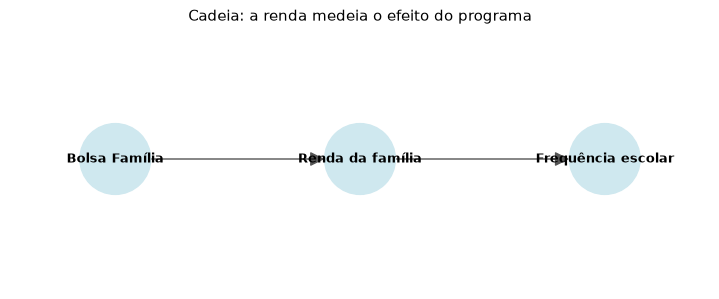

In [48]:
desenha_dag(
    [("Bolsa Família", "Renda da família"),
     ("Renda da família", "Frequência escolar")],
    titulo="Cadeia: a renda medeia o efeito do programa",
    posicoes={"Bolsa Família": (0, 0),
              "Renda da família": (1, 0),
              "Frequência escolar": (2, 0)},
);

**2. Bifurcação (*fork*):** $A \leftarrow C \rightarrow B$.

$C$ é uma **causa comum** — um **confundidor**. 
- Gera correlação entre $A$ e $B$ **sem** que um cause o outro.

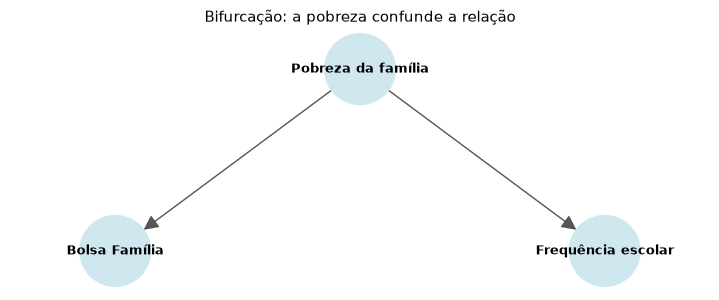

In [49]:
desenha_dag(
    [("Pobreza da família", "Bolsa Família"),
     ("Pobreza da família", "Frequência escolar")],
    titulo="Bifurcação: a pobreza confunde a relação",
    posicoes={"Pobreza da família": (1, 1),
              "Bolsa Família": (0, 0),
              "Frequência escolar": (2, 0)},
);

**3. Colisor (*collider*):** $A \rightarrow K \leftarrow B$.

$K$ recebe setas de dois lados. $A$ e $B$ são independentes...
até **condicionarmos** em $K$.

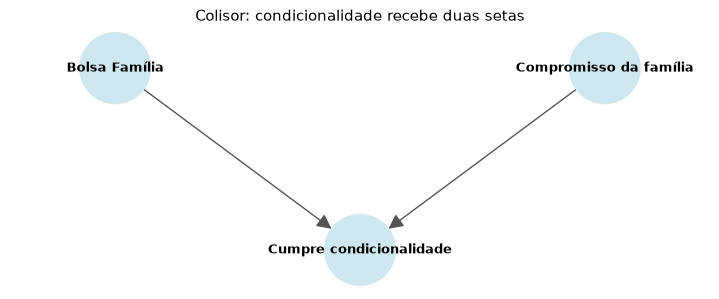

In [50]:
desenha_dag(
    [("Bolsa Família", "Cumpre condicionalidade"),
     ("Compromisso da família", "Cumpre condicionalidade")],
    titulo="Colisor: condicionalidade recebe duas setas",
    posicoes={"Bolsa Família": (0, 0),
              "Cumpre condicionalidade": (1, -1),
              "Compromisso da família": (2, 0)},
);

🚨 A regra que vira do avesso a intuição de quem vem de *Machine Learning*:

- **confundidor** (fork): é preciso **controlar** para tirar o viés;
- **mediador** (chain): controlar **bloqueia** parte do efeito que queremos medir;
- **colisor** (collider): controlar **cria** um viés que não existia.

👉 Em ML, "mais variáveis" raramente faz mal. 
- Em inferência causal, **a variável errada estraga a estimativa**.

### O caminho de fundos (*backdoor*) 🚪

Um **caminho de fundos** liga $D$ a $Y$ começando com uma seta **que aponta para $D$**. 

Ele transmite associação **espúria**.

**Critério de backdoor** (Pearl):

> Para identificar o efeito causal, precisamos **fechar todos os caminhos de fundos** —
> controlando os confundidores — **sem abrir** caminhos novos (sem tocar em
> mediadores e colisores).

👉 Vamos montar o DAG do nosso problema do Bolsa Família.

In [51]:
arestas_pbf = [
    ("Pobreza",          "D"), ("Pobreza",          "Y"),
    ("Escolaridade mãe", "D"), ("Escolaridade mãe", "Y"),
    ("Zona rural",       "D"), ("Zona rural",       "Y"),
    ("Renda atual",      "Y"), ("D",                "Y"),
    ("D",                "Renda atual"),
]

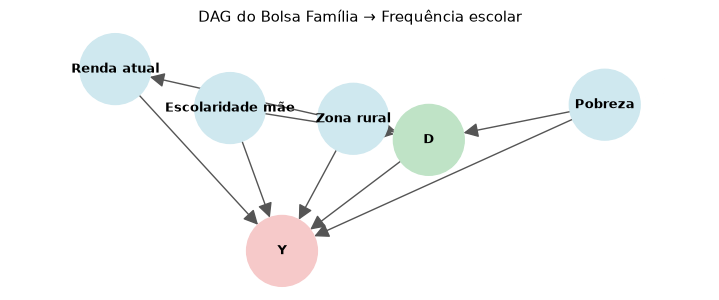

In [52]:
G_pbf = desenha_dag(arestas_pbf, 
                    titulo="DAG do Bolsa Família → Frequência escolar",
                    no_cor={"D": "#bfe3c6", "Y": "#f6c9c9"})

👉 Lendo o DAG:

- **Pobreza**, **Escolaridade da mãe** e **Zona rural** são **confundidores**
  (setas para `D` e para `Y`) → **devem** ser controlados;
- **Renda atual** é **mediador** (`D → Renda atual → Y`): é parte do efeito do
  programa → **não** deve ser controlada;
- a seta direta `D → Y` é o efeito que queremos isolar.

👉 Podemos pedir ao `networkx` a lista de descendentes de `D` — o que **não** se controla.

In [53]:
print("Descendentes de D (NÃO controlar):", nx.descendants(G_pbf, "D"))

Descendentes de D (NÃO controlar): {'Renda atual', 'Y'}


In [54]:
print("DAG é acíclico?", nx.is_directed_acyclic_graph(G_pbf))

DAG é acíclico? True


<details>
  <summary>Quais variáveis fecham os caminhos de fundos? 🤔</summary>

Os caminhos de fundos de `D` a `Y` passam por **Pobreza**, **Escolaridade da mãe**
e **Zona rural**. Controlando essas três, fechamos todos os *backdoors*.

**Renda atual** está num caminho *causal* (`D → Renda atual → Y`), não num backdoor.
Controlá-la removeria parte do efeito do programa — exatamente o que **não** queremos.
</details>

## Bons e Maus Controles 🎛️

Pergunta que parece inocente e não é:

> *"Você controlou por essa variável?"*

Cinelli, Forney & Pearl (2022) mostram que a resposta certa é 
- **depende do papel da variável no DAG**. 

Vamos ver isso **nos dados**.

👉 Vamos estimar o efeito de `D` sobre `Y` adicionando, 
- um a um, controles de tipos diferentes.

### Controle 1 — um confundidor (BOM) ✅

👉 **Zona rural** afeta o acesso à escola **e** a chance de receber o PBF. É confundidor.

In [55]:
m_base = smf.ols("Y ~ D", data=criancas).fit()

In [56]:
m_base.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Y   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.3656
Date:                Sat, 11 Jul 2026   Prob (F-statistic):              0.545
Time:                        16:40:13   Log-Likelihood:                 8692.4
No. Observations:               12441   AIC:                        -1.738e+04
Df Residuals:                   12439   BIC:                        -1.737e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.9677      0.002    482.067      0.000       0.964       0.972
D             -0.0014      0.002     -0.605      0.545      -0.006       0.003
==============================================================================
Omnibus:                    11013.298   Durbin-Watson:                   1.506
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           269461.336
Skew:                          -4.419   Prob(JB):                         0.00
Kurtosis:                      24.017   Cond. No.                         3.49
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [57]:
m_conf = smf.ols("Y ~ D + rural", data=criancas).fit()

In [58]:
m_conf.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Y   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     2.264
Date:                Sat, 11 Jul 2026   Prob (F-statistic):              0.104
Time:                        16:40:13   Log-Likelihood:                 8694.5
No. Observations:               12441   AIC:                        -1.738e+04
Df Residuals:                   12438   BIC:                        -1.736e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.9680      0.002    480.634      0.000       0.964       0.972
D             -0.0012      0.002     -0.502      0.616      -0.006       0.003
rural         -0.0100      0.005     -2.040      0.041      -0.020      -0.000
==============================================================================
Omnibus:                    11015.939   Durbin-Watson:                   1.507
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           269912.028
Skew:                          -4.420   Prob(JB):                         0.00
Kurtosis:                      24.036   Cond. No.                         5.70
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [59]:
pd.DataFrame({
    "modelo": ["Y ~ D", "Y ~ D + rural (confundidor)"],
    "efeito de D": [m_base.params["D"], m_conf.params["D"]],
})

,modelo,efeito de D
0,Y ~ D,-0.001439
1,Y ~ D + rural (confundidor),-0.001196


👉 Controlar um confundidor **corrige** viés — é o uso legítimo do controle.

### Controle 2 — um mediador (MAU) ⛔

👉 A criança **fazer refeição gratuita na escola** (`s03a13`) é um mediador,
- pois está **depois** de `D` no caminho causal, uma vez que
    - o Bolsa Família requer que esteja na escola; e
    - refeição gratuita na escola é consequência de estar na escola.

In [60]:
criancas["merenda"] = (criancas["s03a13"] == 1).astype(int)
m_mediador = smf.ols("Y ~ D + rural + merenda", data=criancas).fit()
m_mediador.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Y   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     3.120
Date:                Sat, 11 Jul 2026   Prob (F-statistic):             0.0249
Time:                        16:40:13   Log-Likelihood:                 8696.9
No. Observations:               12441   AIC:                        -1.739e+04
Df Residuals:                   12437   BIC:                        -1.736e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.9722      0.003    351.497      0.000       0.967       0.978
D             -0.0007      0.002     -0.305      0.760      -0.005       0.004
rural         -0.0103      0.005     -2.103      0.035      -0.020      -0.001
merenda       -0.0057      0.003     -2.198      0.028      -0.011      -0.001
==============================================================================
Omnibus:                    11011.117   Durbin-Watson:                   1.508
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           269514.400
Skew:                          -4.418   Prob(JB):                         0.00
Kurtosis:                      24.020   Cond. No.                         6.78
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [61]:
pd.DataFrame({
    "modelo": ["Y ~ D + rural", "Y ~ D + rural + merenda (mediador)"],
    "efeito de D": [m_conf.params["D"], m_mediador.params["D"]],
})

,modelo,efeito de D
0,Y ~ D + rural,-0.001196
1,Y ~ D + rural + merenda (mediador),-0.000731


🚨 Ao controlar o mediador, o efeito estimado de `D` **se desloca em direção a zero**
- bloqueamos justamente um canal pelo qual o programa age.

ℹ️ Regra: **nunca** controle uma variável que está *depois* do tratamento.

### Controle 3 — um colisor (MAU) ⛔

👉 O colisor é o caso mais traiçoeiro: 
- controlar uma variável que **não existia**
- no caminho de viés **cria** viés do zero.

Para *ver* isso com clareza, vamos a um pequeno **experimento simulado**
- assim conhecemos o efeito verdadeiro e podemos checar quem acerta.

👉 O cenário simulado:

- o efeito **verdadeiro** do tratamento `D` sobre `Y` é **0,30** (nós o definimos);
- existe um fator de família `U` (não observado) que afeta `Y`;
- um colisor `K` recebe seta de **`D`** e de **`U`**

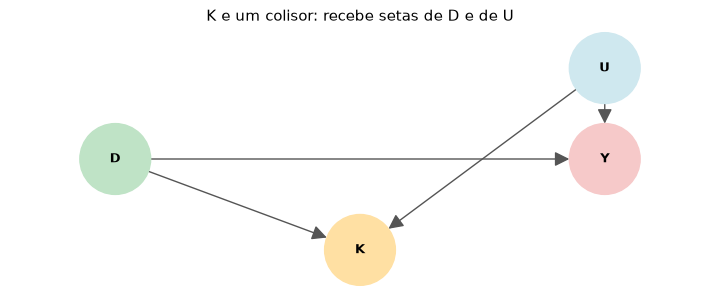

In [62]:
desenha_dag(
    [("D", "K"), ("U", "K"), ("D", "Y"), ("U", "Y")],
    titulo="K e um colisor: recebe setas de D e de U",
    posicoes={"D": (0, 0), "Y": (2, 0), "U": (2, 1), "K": (1, -1)},
    no_cor={"D": "#bfe3c6", "Y": "#f6c9c9", "K": "#ffe0a3"},
);

In [63]:
np.random.seed(42)
n = 2000

D_sim = np.random.binomial(1, 0.5, n)                    # tratamento
U_sim = np.random.normal(0, 1, n)                        # fator de familia (nao observado)
Y_sim = 0.30 * D_sim + 0.50 * U_sim + np.random.normal(0, 1, n)
K_sim = (0.8 * D_sim + 0.8 * U_sim
         + np.random.normal(0, 1, n) > 0).astype(int)    # colisor

simulado = pd.DataFrame({"D": D_sim, "Y": Y_sim, "K": K_sim})
simulado.head()

,D,Y,K
0,0,-0.092281,0
1,1,2.398116,1
2,1,-1.653317,1
3,1,0.451402,0
4,0,1.097335,1


👉 Sabemos a verdade: o efeito de `D` é **0,30**. Vamos estimar **com** e **sem** o colisor.

In [64]:
m_sem_colisor = smf.ols("Y ~ D",     data=simulado).fit()
m_sem_colisor.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Y   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     26.09
Date:                Sat, 11 Jul 2026   Prob (F-statistic):           3.57e-07
Time:                        16:40:14   Log-Likelihood:                -3038.7
No. Observations:                2000   AIC:                             6081.
Df Residuals:                    1998   BIC:                             6093.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0099      0.035     -0.281      0.779      -0.079       0.059
D              0.2527      0.049      5.108      0.000       0.156       0.350
==============================================================================
Omnibus:                        0.269   Durbin-Watson:                   2.033
Prob(Omnibus):                  0.874   Jarque-Bera (JB):                0.334
Skew:                           0.006   Prob(JB):                        0.846
Kurtosis:                       2.938   Cond. No.                         2.63
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [65]:
m_com_colisor = smf.ols("Y ~ D + K", data=simulado).fit()
m_com_colisor.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Y   R-squared:                       0.063
Model:                            OLS   Adj. R-squared:                  0.062
Method:                 Least Squares   F-statistic:                     66.95
Date:                Sat, 11 Jul 2026   Prob (F-statistic):           7.23e-29
Time:                        16:40:14   Log-Likelihood:                -2986.8
No. Observations:                2000   AIC:                             5980.
Df Residuals:                    1997   BIC:                             5996.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.2734      0.043     -6.390      0.000      -0.357      -0.189
D              0.1235      0.050      2.480      0.013       0.026       0.221
K              0.5296      0.051     10.316      0.000       0.429       0.630
==============================================================================
Omnibus:                        0.509   Durbin-Watson:                   2.027
Prob(Omnibus):                  0.775   Jarque-Bera (JB):                0.576
Skew:                          -0.012   Prob(JB):                        0.750
Kurtosis:                       2.920   Cond. No.                         3.32
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [66]:
pd.DataFrame({
    "modelo": ["Y ~ D", "Y ~ D + K (colisor)"],
    "efeito de D": [m_sem_colisor.params["D"], 
                    m_com_colisor.params["D"]],
    "efeito verdadeiro": [0.30, 0.30],
})

,modelo,efeito de D,efeito verdadeiro
0,Y ~ D,0.252713,0.3
1,Y ~ D + K (colisor),0.123538,0.3


🚨 Sem o colisor, a estimativa fica perto de **0,30** (a verdade).
- Controlando o colisor `K`, ela **desaba**
    - um viés que **nós criamos** ao adicionar a variável.

ℹ️ Filtrar a amostra por uma variável também é condicionar nela. 
- Filtrar por um colisor enviesa do mesmo jeito.

### O quadro-resumo 🗂️

| Tipo no DAG | Exemplo no PBF | Controlar? |
|---|---|---|
| Confundidor (*fork*) | pobreza, zona rural, escolaridade da mãe | ✅ **Sim** |
| Mediador (*chain*) | renda atual, merenda escolar | ⛔ **Não** |
| Colisor (*collider*) | evasão, cumprir condicionalidade | ⛔ **Não** |
| Descendente do tratamento | qualquer efeito de `D` | ⛔ **Não** |

🚨 **Mantra do curso:** controle confundidores; 
- nunca controle mediadores, colisores ou descendentes do tratamento.

👉 Vamos visualizar como o efeito estimado **se desloca** conforme o controle.

🚨 Nota de leitura: 
- as duas primeiras barras vêm dos dados reais da AIBF (efeito sobre `p_attend7`);
- as duas últimas, do experimento simulado (efeito de `D`, verdade = 0,30).

O ponto **não** é comparar a altura entre os dois pares
- é ver que, **em cada par**, o controle errado **desloca** a estimativa.

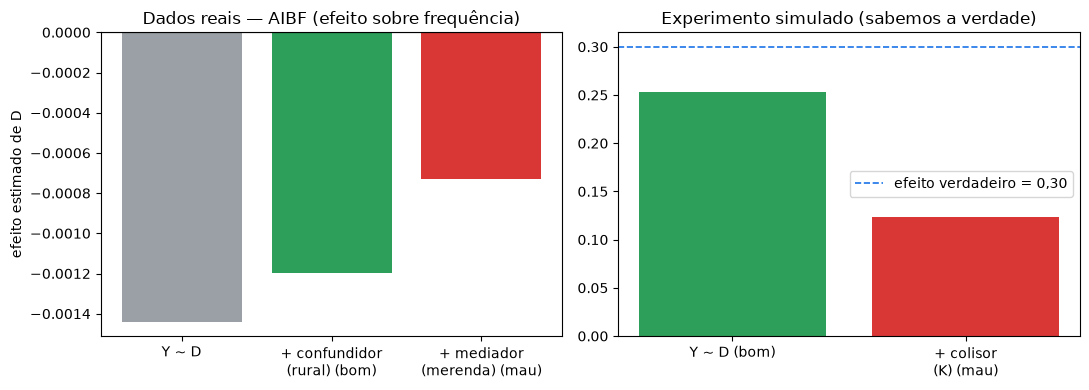

In [67]:
fig, eixos = plt.subplots(1, 2, figsize=(11, 4))

# --- Painel 1: dados reais da AIBF ---
reais = pd.DataFrame({
    "espec": ["Y ~ D", "+ confundidor\n(rural) (bom)", "+ mediador\n(merenda) (mau)"],
    "efeito": [m_base.params["D"], m_conf.params["D"], m_mediador.params["D"]],
})
eixos[0].bar(reais["espec"], reais["efeito"],
             color=["#9aa0a6", "#2e9e5b", "#d93636"])
eixos[0].axhline(0, color="black", lw=0.8)
eixos[0].set_title("Dados reais — AIBF (efeito sobre frequência)")
eixos[0].set_ylabel("efeito estimado de D")

# --- Painel 2: experimento simulado (verdade = 0,30) ---
sim = pd.DataFrame({
    "espec": [r"Y ~ D (bom)", "+ colisor\n(K) (mau)"],
    "efeito": [m_sem_colisor.params["D"], m_com_colisor.params["D"]],
})
eixos[1].bar(sim["espec"], sim["efeito"], color=["#2e9e5b", "#d93636"])
eixos[1].axhline(0.30, color="#1a73e8", ls="--", lw=1.2,
                 label="efeito verdadeiro = 0,30")
eixos[1].set_title("Experimento simulado (sabemos a verdade)")
eixos[1].legend()

plt.tight_layout();

🚨 Quatro análises, quatro números — todos do **mesmo** dataset.

A diferença não está nos dados; está nas **hipóteses causais**. 

👉 Sem um DAG explícito, "controlar variáveis" é tiro no escuro.

## Exercício 🏋️

👉 Até aqui o desfecho foi a **frequência** escolar (`p_attend7`). 

Mas ela tem um problema: quase toda criança frequenta ~97% dos dias, então sobra pouca variação para analisar.

Neste exercício você troca de desfecho e refaz o raciocínio da aula **sozinho**.

ℹ️ **Novo desfecho — `if_miss30`.** 
- Vale `1` se a criança **faltou** à escola pelo menos uma vez nos últimos 30 dias, e
- `0` caso contrário.

🚨 Atenção à leitura: 
- agora, um valor **maior** é um resultado **pior** 
    - (é o oposto da frequência.)
- Isso vai inverter o sinal de tudo. Pense nisso ao interpretar.

👉 **Tarefa 1.** Monte a amostra de crianças de 6 a 17 anos com `if_miss30` observado e...

Calcule a **diferença simples** de médias entre tratados e controles. 

Complete os trechos `...`.

In [68]:
exerc = df[df["s02af"].between(6, 17) & df["if_miss30"].notna()].copy()
exerc["faltou"]   = exerc["if_miss30"]
exerc["rural"]    = exerc["s02a21"].isin([2, 4]).astype(int)
exerc["feminino"] = (exerc["s02ad"] == 2).astype(int)
exerc["preta_parda"] = exerc["s02a17"].isin([2, 3]).astype(int)
exerc["regiao"]   = exerc["s00a1"] // 10

# complete: use a função diferenca_de_medias com o desfecho "faltou"
tabela_ex, dif_ex = diferenca_de_medias(exerc, "D", "faltou")
tabela_ex

,count,mean
D,,
0,3664,0.260371
1,9130,0.286309


<details>
  <summary>Tarefa 1 — resposta</summary>

```python
tabela_ex, dif_ex = diferenca_de_medias(exerc, "D", "faltou")
tabela_ex
```

A diferença simples é de cerca de **+0,03**: na leitura ingênua, as crianças beneficiárias **faltam mais**. Sinal positivo — mas, como `if_miss30` mede ausência, positivo é resultado *ruim*. É o mesmo viés de seleção da aula, agora aparecendo num desfecho invertido.
</details>

👉 **Tarefa 2.** Estime o efeito de `D` sobre `faltou` em dois modelos:
- só com `D` e
- com as covariáveis

Compare-os. O sinal se inverte? Aproxima de zero?

In [69]:
mod_simples_ex  = smf.ols("faltou ~ D", data=exerc).fit()
mod_ajustado_ex = smf.ols(
    "faltou ~ D + s02af + feminino + rural + preta_parda + C(regiao)",
    data=exerc,
).fit()

pd.DataFrame({
    "modelo": ["faltou ~ D", "faltou ~ D + covariáveis"],
    "efeito de D": [mod_simples_ex.params["D"],
                    mod_ajustado_ex.params["D"]],
})

,modelo,efeito de D
0,faltou ~ D,0.025938
1,faltou ~ D + covariáveis,0.015552


<details>
  <summary>Tarefa 2 — o que observar</summary>

Ao incluir as covariáveis, o coeficiente de `D` **cai** — de cerca de **+0,026** para **+0,016**. 

O ajuste explicou parte da diferença bruta (aproximadamente 40%), mas **não toda**: sobra um efeito positivo.

👉 Duas leituras se combinam aqui. 
- Primeira: havia mesmo viés de seleção, e controlar observáveis o reduziu. 
- Segunda: o que sobra (+0,016) **não** é necessariamente o efeito causal
    - pode ser viés remanescente de um confundidor que não medimos.

🚨 Ajustar a regressão raramente "resolve" de uma vez: 
- costuma mover a estimativa na direção certa sem garantir que se chegou ao destino.
Só o desenho do estudo garante a leitura causal.
</details>

👉 **Tarefa 3 (discussão, sem código).** Olhe o DAG do Bolsa Família que desenhamos na aula. 

Se trocarmos o desfecho `Y` de *frequência* para *faltar* (`if_miss30`):

- a `merenda escolar` continua sendo um **mau controle**? por quê?
- e a `renda atual` da família?

<details>
  <summary>Tarefa 3 — resposta</summary>

Sim, os dois continuam **maus controles** — e pela mesma razão de antes: o papel de uma variável no DAG **não muda** quando trocamos o desfecho por outro que esteja no mesmo ponto do grafo.

Tanto `merenda` quanto `renda atual` estão **depois** de `D` no caminho causal (são mediadores: o programa age sobre elas, e elas afetam a ida à escola). Controlar qualquer uma bloqueia parte do efeito do PBF — independentemente de o desfecho ser *frequentar* ou *faltar*.

👉 Lição: o DAG é sobre os **mecanismos**, não sobre o rótulo do desfecho. Confundidor, mediador e colisor seguem sendo o que são.
</details>

## Síntese e Próximo Módulo 🎯

👉 O que levamos deste módulo:

- **Correlação ≠ causalidade.** A diferença simples de médias misturou
    - o efeito do programa com o **viés de seleção**.
- **Resultados potenciais.** Todo efeito é uma comparação $Y(1)$ vs. $Y(0)$;
    - o problema fundamental é só observarmos **um** dos mundos.
- **ATE, ATT, ATU** respondem a perguntas de política diferentes.
- **SUTVA** é a hipótese silenciosa:
    - sem interferência e com versão única do tratamento.
- **DAGs** tornam explícitas as hipóteses causais e revelam **quem** controlar.
- **Bons e maus controles:** confundidor sim; mediador, colisor e descendente, não.

🚨 A pergunta que abriu a aula 
— *o Bolsa Família aumentou a frequência escolar?*
- **continua em aberto**. 

Isso é uma vitória: 
- agora sabemos *por que* a resposta ingênua (`−0,01`) não serve, e 
- o que é preciso para respondê-la com credibilidade.

👉 **Para casa.**

1. Escolha uma política pública que você conheça
    - (PRONATEC, ProUni, Mais Médicos, Farmácia Popular...).
2. Desenhe o **DAG** dela:
    - tratamento,
    - desfecho,
    - ao menos **3 confundidores**, **1 mediador** e **1 colisor**.
3. Liste quais variáveis você controlaria
    - e **justifique** pelo DAG.

👉 **Próximo Módulo — Experimentos Aleatorizados.**

Veremos por que o **sorteio** zera o viés de seleção, 
- como desenhar um experimento, e
- calcular seu **poder estatístico**.

#### Saiba Mais 👩‍🏫

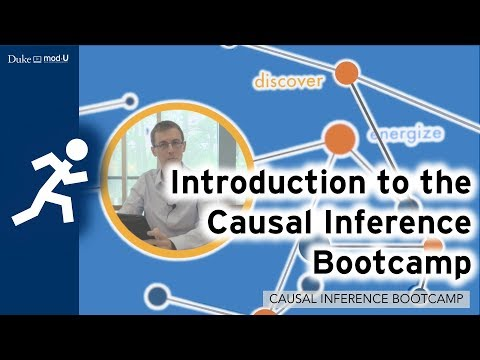

In [70]:
YouTubeVideo(id="FNpcwiOme1g", width="100%")

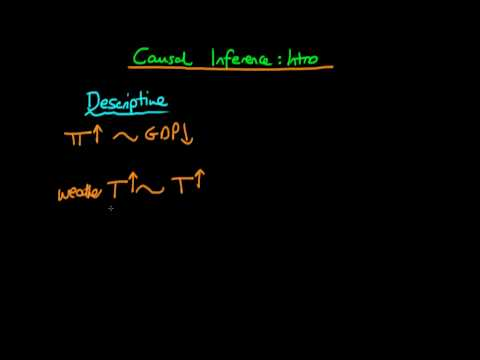

In [71]:
YouTubeVideo(id="Sqy_b5OSiXw", width="100%")

#### Referências 📚

- ANGRIST, J.; PISCHKE, J.-S. *Mostly Harmless Econometrics*. Princeton, 2009. (cap. 2 e 3)
- CINELLI, C.; FORNEY, A.; PEARL, J. A Crash Course in Good and Bad Controls.
  *Sociological Methods & Research*, 2022.
- CUNNINGHAM, S. *Causal Inference: The Mixtape*. Yale, 2021. (cap. 3 e 4)
- FACURE, M. *Causal Inference for the Brave and True*. (caps. 1 e 4)
- HOLLAND, P. Statistics and Causal Inference. *JASA*, 81(396), 1986.
- IMBENS, G.; RUBIN, D. *Causal Inference for Statistics, Social, and Biomedical
  Sciences*. Cambridge, 2015. (cap. 1)
- PEARL, J.; GLYMOUR, M.; JEWELL, N. *Causal Inference in Statistics: A Primer*.
  Wiley, 2016.
- BRASIL. Ministério do Desenvolvimento Social. *Avaliação de Impacto do Bolsa
  Família — 2ª rodada (AIBF II)*. SAGI, 2012.

👉 **Executem todo este caderno** antes da próxima aula e tragam dúvidas. 🚀